# Modelos clásicos

## Librerías y Carga de Datos

* Se define si se utilizará Plotly para las gráficas y se importan las librerías necesarias para análisis de datos, visualización y modelado de series temporales.

Recomendaciones:  Para un mejor entendimiento de las gráficas o su uso local cambiar el valor de `USE_PLOTRLY` a `True`

In [1]:
USE_PLOTLY = True

### Librerías

In [2]:
import sys
sys.path.append('../../')

from src.utils import helpers as func
from src.utils.ts_diagnostics import StationarityAnalyzer, analyze_decomposition
import numpy as np
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf as sm_plot_acf
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from arch import arch_model
from scipy.stats import t # Para usar la distribución t si se elige en GARCH

# Para Auto ARIMA
import pmdarima as pm
from pmdarima import model_selection
import warnings

### Carga de Datos

* Se carga el conjunto de datos procesado utilizando una función personalizada, preparando el DataFrame para el análisis.

In [3]:
path = '../../data/processed/df_acumulado.parquet'
df = func.load_data(path,show_info=False)

Cargando datos desde: ../../data/processed/df_acumulado.parquet
Datos cargados exitosamente.


## Análisis de la Serie Temporal

### Serie Original por Casos Semanales

* Se seleccionan las columnas relevantes y se grafica la serie temporal acumulada para observar su comportamiento general.

In [4]:
# Dataframe con las columnas necesarias para el análisis de series temporales
df_sem = df[['fecha', 'valor_acumulado_corregido']].copy()
df_sem.rename(columns={'valor_acumulado_corregido': 'valor'}, inplace=True)

df_sem['valor'] = df_sem['valor'].diff().fillna(0)
df_sem.iloc[0, df_sem.columns.get_loc('valor')] = 131

x= 'fecha'
y= 'valor'
title = 'Serie de tiempo General (Casos nuevos semanales)'
# Gráfica de línea con plotly / seaborn según selección del usuario
func.plot_timeseries(df_sem, x=x, y=y, title=title, plotly_engine=USE_PLOTLY)

#### Descripción de gráfico
El nuevo gráfico de serie de tiempo con **Casos Nuevos Semanales** de depresión, revela una tendencia de **crecimiento sostenido** a largo plazo, a pesar de las fluctuaciones. Se observa una estacionalidad con caídas recurrentes (valles) al final de cada año. El período **2020-2021** muestra una interrupción y posterior recuperación en el ritmo de reporte, y los años recientes (2023-2024) exhiben **picos inusualmente altos** de casos nuevos, lo que sugiere un aumento en la detección o el reporte, aunque con una alta variabilidad.

#### Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido

* Se descompone la serie en sus componentes de tendencia, estacionalidad y ruido para identificar patrones subyacentes.

In [5]:
ts_data_incremento = df_sem.set_index('fecha')['valor']

# Mostrar las primeras filas de la serie temporal preparada
print("Serie temporal preparada para descomposición:")
display(ts_data_incremento.head())

Serie temporal preparada para descomposición:


fecha
2014-01-06     131.0
2014-01-13     658.0
2014-01-20     933.0
2014-01-27    1023.0
2014-02-03    1151.0
Name: valor, dtype: float64

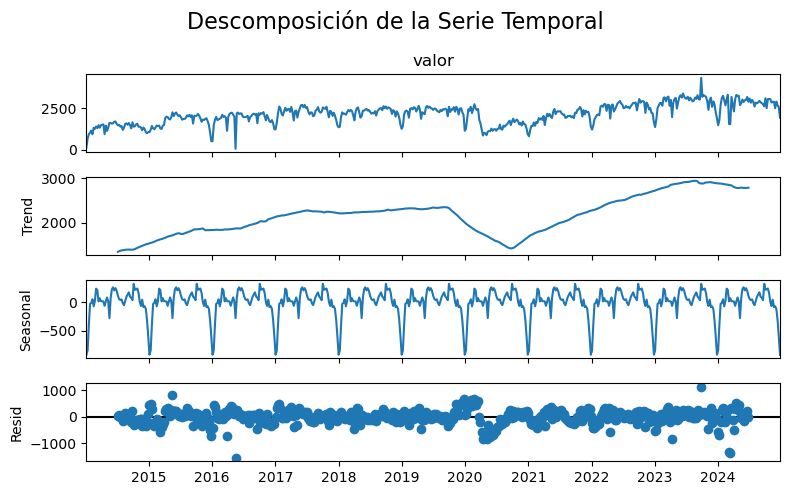

In [6]:
# Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido
decomposition = analyze_decomposition(ts_data_incremento, model='additive', figsize=(8, 5))

##### **Análisis de la Descomposición de la Serie**

**Tendencia (Trend):** La tendencia exhibe un crecimiento sostenido y gradual desde 2014 hasta 2019. Luego, muestra una caída abrupta que coincide con el inicio de 2020, seguida de una fuerte recuperación y un crecimiento continuo que alcanza su punto máximo a finales de 2023. Esta interrupción y posterior aceleración sugiere un impacto significativo del COVID-19 en el reporte de nuevos casos, seguido de una normalización y aumento en la detección.

**Estacionalidad (Seasonal):** Se revela un patrón cíclico anual extremadamente fuerte y bien definido. La estacionalidad es multiplicativa o aditiva con alta amplitud, caracterizada por caídas profundas y recurrentes (valles) al final de cada ciclo anual. Esto indica que el reporte de nuevos casos tiene un componente predecible que se ve afectado por factores estacionales o calendarios (como vacaciones de fin de año).

**Residuos (Resid):** Los residuos se dispersan de manera aleatoria alrededor de la línea cero, pero con la presencia de valores atípicos significativos. Se observan puntos extremos (tanto positivos como negativos) especialmente en el período 2020-2021, lo que sugiere que las semanas individuales de la pandemia tuvieron un ruido o anomalías que no son explicadas por la tendencia o el patrón estacional.

La serie de tiempo de casos nuevos semanales es no estacionaria debido a una fuerte tendencia de crecimiento a largo plazo (interrumpida en 2020) y una estacionalidad anual profunda y persistente. La presencia de un alto ruido en los residuos, especialmente alrededor de la pandemia, indica que esta serie requerirá diferenciación para eliminar la tendencia y potencialmente un tratamiento de valores atípicos antes de cualquier modelado predictivo robusto.

#### Pruebas de estacionariedad

* Se aplican pruebas estadísticas para determinar si la serie es estacionaria, es decir, si sus propiedades estadísticas son constantes en el tiempo.

In [7]:
tester_ts_data_incremento = StationarityAnalyzer(ts_data_incremento)

tester_ts_data_incremento.run_test(test_type='ADF', show_report=True)
tester_ts_data_incremento.run_test(test_type='KPSS', show_report=True)


Resultados de la prueba ADF:
╒═════════════════╤════════════════╤════════════════════════╕
│ Métrica         │   Valor Prueba │   Valor Crítico (5.0%) │
╞═════════════════╪════════════════╪════════════════════════╡
│ Estadístico ADF │        -2.577  │                -2.8667 │
├─────────────────┼────────────────┼────────────────────────┤
│ p-value         │         0.0978 │                 0.05   │
╘═════════════════╧════════════════╧════════════════════════╛

Resultados de la prueba KPSS:
╒══════════════════╤════════════════╤════════════════════════╕
│ Métrica          │   Valor Prueba │   Valor Crítico (5.0%) │
╞══════════════════╪════════════════╪════════════════════════╡
│ Estadístico KPSS │         1.8196 │                  0.463 │
├──────────────────┼────────────────┼────────────────────────┤
│ p-value          │         0.01   │                  0.05  │
╘══════════════════╧════════════════╧════════════════════════╛


c:\Users\steph\Documents\proyecto-integrador-mna\notebooks\modeling\../..\src\utils\ts_diagnostics.py:84: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




##### Análisis de Resultados: Prueba ADF

El Estadístico ADF ($-2.577$) es mayor (menos negativo) que el valor crítico al $5\%$ ($-2.8667$), y el valor p ($0.0978$) es mayor que $0.05$. Por lo tanto, no se rechaza la hipótesis nula de no estacionariedad. La prueba ADF concluye que la serie de Casos Nuevos Semanales no es estacionaria.

##### Análisis de Resultados: Prueba KPSS

El Estadístico KPSS ($1.8196$) es significativamente mayor que el valor crítico al $5\%$ ($0.463$), y el valor p ($0.01$) es menor que $0.05$. Dado que la es de estacionariedad, esta hipótesis es rechazada. La prueba KPSS también concluye que la serie no es estacionaria.

### Función de autocorrelación (ACF)

In [8]:
def plot_acf_series(ts, lags=52, use_plotly=USE_PLOTLY, title='Función de Autocorrelación (ACF)'):
    """
    Calcula y muestra la ACF de una serie temporal.
    Devuelve (acf_values, confint).
    """
    # Preparar serie
    series = ts.dropna()
    if series.empty:
        raise ValueError("La serie está vacía.")
    
    # Calcular ACF y límites de confianza (alpha=0.05)
    acf_vals, confint = acf(series, nlags=lags, alpha=0.05, fft=True)
    lags_arr = np.arange(len(acf_vals))

    if use_plotly:
        # mitad del ancho del intervalo de confianza para barras de error
        err = (confint[:, 1] - confint[:, 0]) / 2
        fig = go.Figure()
        fig.add_trace(go.Bar(x=lags_arr, y=acf_vals, marker_color='steelblue', name='ACF',
                             error_y=dict(type='data', array=err, visible=True)))
        fig.add_hline(y=0, line_dash="dash", line_color="black")
        fig.update_layout(title=title, xaxis_title='Lag', yaxis_title='ACF', template='plotly_white')
        fig.show()
    else:
        plt.figure(figsize=(10, 4))
        sm_plot_acf(series, lags=lags, alpha=0.05)
        plt.title(title)
        plt.tight_layout()
        plt.show()

    return acf_vals, confint

In [9]:
acf_vals, confint = plot_acf_series(ts_data_incremento, lags=52, use_plotly=USE_PLOTLY)

El gráfico de la **Función de Autocorrelación (ACF)** para la serie **original** de diagnósticos de depresión revela una **no estacionariedad** clara. La característica principal es el **decaimiento lento y persistente** de la autocorrelación, que se mantiene significativamente por encima de los intervalos de confianza (las barras de error) incluso después de 52 *lags* (un año). Este patrón es el sello distintivo de una serie con una **tendencia** subyacente o una **raíz unitaria**, lo que significa que los valores pasados tienen una influencia muy duradera en los valores futuros.

### Serie Original por Casos Semanales (Diff)

In [10]:
df_diff = df_sem.copy()
df_diff = df_diff.set_index('fecha').diff().dropna().reset_index()
x= 'fecha'
y= 'valor'
title = 'Serie de tiempo General (Casos nuevos semanales, Diff)'
# Gráfica de línea con plotly / seaborn según selección del usuario
func.plot_timeseries(df_diff, x=x, y=y, title=title, plotly_engine=USE_PLOTLY)

In [11]:
ts_data_diff = df_diff.set_index('fecha')['valor']

# Mostrar las primeras filas de la serie temporal preparada
print("Serie temporal preparada para descomposición:")
display(ts_data_diff.head())

Serie temporal preparada para descomposición:


fecha
2014-01-13    527.0
2014-01-20    275.0
2014-01-27     90.0
2014-02-03    128.0
2014-02-10   -224.0
Name: valor, dtype: float64

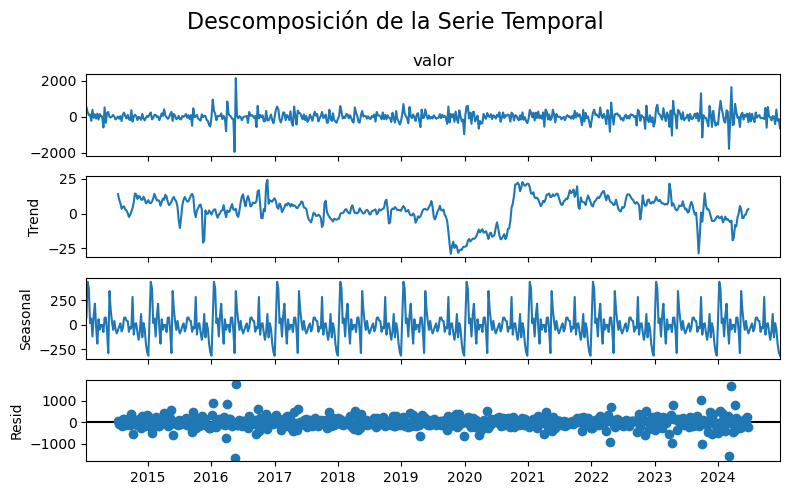

In [12]:
# Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido
decomposition = analyze_decomposition(ts_data_diff, model='additive', figsize=(8, 5))

##### **Análisis de la Descomposición de la Serie**

**Tendencia (Trend):** La línea ya no muestra una dirección clara y persistente (ascendente o descendente). En su lugar, oscila alrededor de cero. Esto confirma visualmente que la diferenciación eliminó la tendencia de la media no estacionaria que vimos en la serie original.

**Estacionalidad (Seasonal):** Muestra un patrón repetitivo claro, con picos y valles regulares. Dado que la serie es semanal, este patrón es probablemente anual (cada 52 semanas).

**Residuos (Resid):** La mayoría de los puntos están centrados alrededor de cero, sin patrones obvios ni varianza creciente. Esto indica que la tendencia y la estacionalidad han sido capturadas de manera efectiva por la descomposición.

In [13]:
tester_ts_data_log = StationarityAnalyzer(ts_data_diff)

tester_ts_data_log.run_test(test_type='ADF', show_report=True)
tester_ts_data_log.run_test(test_type='KPSS', show_report=True)


Resultados de la prueba ADF:
╒═════════════════╤════════════════╤════════════════════════╕
│ Métrica         │   Valor Prueba │   Valor Crítico (5.0%) │
╞═════════════════╪════════════════╪════════════════════════╡
│ Estadístico ADF │        -8.8196 │                -2.8668 │
├─────────────────┼────────────────┼────────────────────────┤
│ p-value         │         0      │                 0.05   │
╘═════════════════╧════════════════╧════════════════════════╛

Resultados de la prueba KPSS:
╒══════════════════╤════════════════╤════════════════════════╕
│ Métrica          │   Valor Prueba │   Valor Crítico (5.0%) │
╞══════════════════╪════════════════╪════════════════════════╡
│ Estadístico KPSS │         0.1602 │                  0.463 │
├──────────────────┼────────────────┼────────────────────────┤
│ p-value          │         0.1    │                  0.05  │
╘══════════════════╧════════════════╧════════════════════════╛


c:\Users\steph\Documents\proyecto-integrador-mna\notebooks\modeling\../..\src\utils\ts_diagnostics.py:84: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




**ADF**

$-8.8196$ Es mucho más negativo que el valor crítico de $-2.8668$ y el p-value $0$ es menor que el nivel de significancia $\alpha=0.05$. Por lo que se rechaza la hipótesis nula ($H_0$). La prueba confirma que la serie diferenciada ES estacionaria en la media.

**KPSS**
$0.1602$ Es menor que el valor crítico de $0.463$ y el p-value $0.1$ es mayor que el nivel de significancia $\alpha=0.05$.Por lo que no se rechaza la hipótesis nula ($H_0$). La prueba confirma que la serie diferenciada ES estacionaria.

In [14]:
acf_vals, confint = plot_acf_series(ts_data_diff, lags=52, use_plotly=USE_PLOTLY)

### Serie Original por Casos Semanales (log)

* Se aplican transformaciones de logaritmo para estabilizar la varianza y facilitar la modelación.

In [15]:
df_log = df_sem.copy()
df_log['valor'] = np.log1p(df_log['valor'])
x= 'fecha'
y= 'valor'
title = 'Serie de tiempo General (Casos nuevos semanales)'
# Gráfica de línea con plotly / seaborn según selección del usuario
func.plot_timeseries(df_log, x=x, y=y, title=title, plotly_engine=USE_PLOTLY)

#### Descripción de gráfico
El gráfico muestra la serie de tiempo de **Casos Nuevos Semanales después de aplicar la transformación logarítmica**. La transformación ha sido exitosa en **estabilizar la varianza**, haciendo que la amplitud de las fluctuaciones a lo largo del tiempo sea más uniforme, lo que es un pre-requisito esencial para el modelado. No obstante, la serie **aún exhibe claramente la tendencia de crecimiento** a largo plazo (la media sigue subiendo) y mantiene las caídas estacionales periódicas (valles) al final de cada año. La presencia de la tendencia y de la estacionalidad implica que la serie **todavía no es estacionaria**.

#### Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido

* Se descompone la serie en sus componentes de tendencia, estacionalidad y ruido para identificar patrones subyacentes.

In [16]:
ts_data_log = df_log.set_index('fecha')['valor']

# Mostrar las primeras filas de la serie temporal preparada
print("Serie temporal preparada para descomposición:")
display(ts_data_log.head())

Serie temporal preparada para descomposición:


fecha
2014-01-06    4.882802
2014-01-13    6.490724
2014-01-20    6.839476
2014-01-27    6.931472
2014-02-03    7.049255
Name: valor, dtype: float64

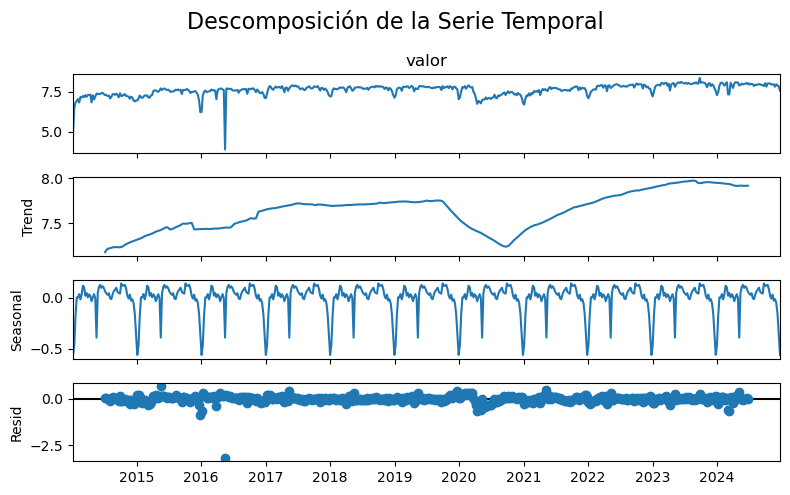

In [17]:
# Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido
decomposition = analyze_decomposition(ts_data_log, model='additive', figsize=(8, 5))

##### **Análisis de la Descomposición de la Serie**

**Tendencia (Trend):** La tendencia revela un crecimiento ascendente hasta finales de 2019, seguido de una caída abrupta durante 2020 y una fuerte recuperación y crecimiento continuo hasta 2023. La transformación logarítmica ha hecho que la pendiente de la tendencia sea más uniforme antes de la interrupción de 2020. A pesar de la transformación, la tendencia de crecimiento persiste, lo que confirma que la serie no es estacionaria en media.

**Estacionalidad (Seasonal):** Se mantiene un patrón cíclico anual muy fuerte y claro, caracterizado por valles recurrentes al final de cada ciclo anual. La transformación logarítmica fue efectiva en estabilizar la amplitud de estas caídas, haciendo que la estacionalidad sea aditiva, lo cual facilita la modelación.

**Residuos (Resid):** Muestran una varianza estable (la dispersión es uniforme) alrededor de la línea cero, lo cual es el efecto deseado de la transformación logarítmica. Sin embargo, persisten anomalías discretas (picos y valles), particularmente la perturbación vista en 2020-2021, que no es explicada por la tendencia o la estacionalidad.

La serie de tiempo logarítmica no es estacionaria debido a la persistencia de la tendencia y de una fuerte estacionalidad. La transformación logró estabilizar la varianza, pero la serie aún requiere un paso de diferenciación para eliminar la tendencia restante y cumplir con los requisitos de estacionariedad para modelos de pronóstico como SARIMA.

#### Pruebas de estacionariedad

* Se aplican pruebas estadísticas para determinar si la serie es estacionaria, es decir, si sus propiedades estadísticas son constantes en el tiempo.

In [18]:
tester_ts_data_log = StationarityAnalyzer(ts_data_log)

tester_ts_data_log.run_test(test_type='ADF', show_report=True)
tester_ts_data_log.run_test(test_type='KPSS', show_report=True)


Resultados de la prueba ADF:
╒═════════════════╤════════════════╤════════════════════════╕
│ Métrica         │   Valor Prueba │   Valor Crítico (5.0%) │
╞═════════════════╪════════════════╪════════════════════════╡
│ Estadístico ADF │        -4.223  │                -2.8667 │
├─────────────────┼────────────────┼────────────────────────┤
│ p-value         │         0.0006 │                 0.05   │
╘═════════════════╧════════════════╧════════════════════════╛

Resultados de la prueba KPSS:
╒══════════════════╤════════════════╤════════════════════════╕
│ Métrica          │   Valor Prueba │   Valor Crítico (5.0%) │
╞══════════════════╪════════════════╪════════════════════════╡
│ Estadístico KPSS │         1.7704 │                  0.463 │
├──────────────────┼────────────────┼────────────────────────┤
│ p-value          │         0.01   │                  0.05  │
╘══════════════════╧════════════════╧════════════════════════╛


c:\Users\steph\Documents\proyecto-integrador-mna\notebooks\modeling\../..\src\utils\ts_diagnostics.py:84: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




##### Análisis de Resultados: Prueba ADF

El Estadístico ADF ($-4.223$) es significativamente menor (más negativo) que el valor crítico al $5\%$ ($-2.8667$). Además, el valor p ($0.0006$) es mucho menor que $0.05$. Por lo tanto, se rechaza la hipótesis nula de no estacionariedad. La prueba concluye que la serie logarítmica es estacionaria en media y varianza.


##### Análisis de Resultados: Prueba KPSS

Interpretación KPSS:
El Estadístico KPSS ($1.7704$) es sustancialmente mayor que el valor crítico al $5\%$ ($0.463$), y el valor p ($0.01$) es menor que $0.05$. Por lo tanto, la hipótesis nula de estacionariedad es rechazada. La prueba KPSS concluye que la serie logarítmica no es estacionaria.

### Función de autocorrelación (ACF)

In [19]:
acf_vals, confint = plot_acf_series(ts_data_log, lags=52, use_plotly=USE_PLOTLY)

### Serie Original por Casos Semanales (log + Diff)

* Se seleccionan las columnas relevantes y se grafica la serie temporal acumulada para observar su comportamiento general.

In [20]:
df_log_diff = df_log.copy()
df_diff1 = df_log_diff.set_index('fecha').diff().dropna().reset_index()

x= 'fecha'
y= 'valor'
title = 'Serie de tiempo General (Casos nuevos semanales)'
# Gráfica de línea con plotly / seaborn según selección del usuario
func.plot_timeseries(df_diff1, x=x, y=y, title=title, plotly_engine=USE_PLOTLY)

In [21]:
df_diff1['fecha'] = pd.to_datetime(df_diff1['fecha'])

# Filtra por el año 2016 y la semana 20
df_filtrado = df_diff1[
    (df_diff1['fecha'].dt.isocalendar().year == 2016) & 
    (df_diff1['fecha'].dt.isocalendar().week == 21)
]

# Imprime el resultado
print(df_filtrado)

         fecha     valor
123 2016-05-23  3.803938


#### Descripción de gráfico
El gráfico muestra la serie de tiempo de **Casos Nuevos Semanales después de aplicar una diferenciación a la serie transformada logarítmicamente (Log-Diff)**. La diferenciación ha sido **completamente exitosa en eliminar la tendencia** y estabilizar la media de la serie, la cual ahora oscila de manera estable alrededor de cero, cumpliendo con el requisito fundamental de **estacionariedad**. La varianza también es constante, con la mayor parte del ruido concentrada cerca de la línea de base, a excepción de un **valor atípico extremo** alrededor de 2016 y otro al inicio de 2014, lo que sugiere anomalías en el registro de la tasa de crecimiento durante esas semanas.

#### Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido

* Se descompone la serie en sus componentes de tendencia, estacionalidad y ruido para identificar patrones subyacentes.

In [22]:
ts_data_diff1 = df_diff1.set_index('fecha')['valor']

# Mostrar las primeras filas de la serie temporal preparada
print("Serie temporal preparada para descomposición:")
display(ts_data_diff1.head())

Serie temporal preparada para descomposición:


fecha
2014-01-13    1.607922
2014-01-20    0.348753
2014-01-27    0.091995
2014-02-03    0.117783
2014-02-10   -0.216223
Name: valor, dtype: float64

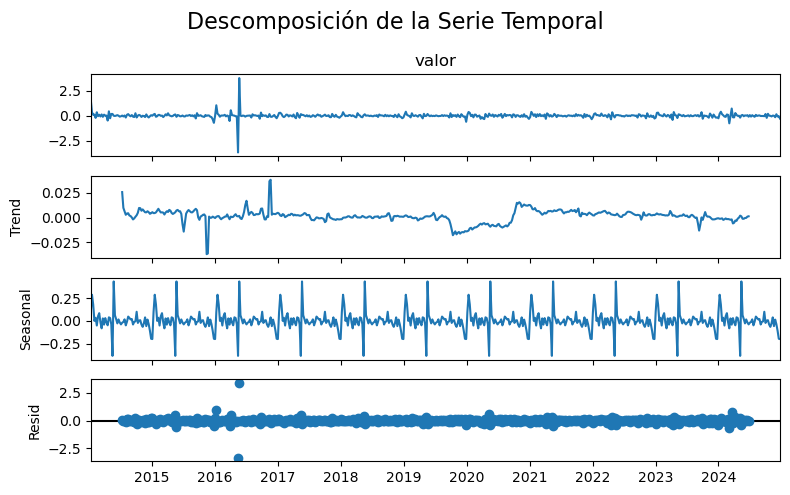

In [23]:
# Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido
decomposition = analyze_decomposition(ts_data_diff1, model='additive', figsize=(8, 5))

##### **Análisis de la Descomposición de la Serie**

**Tendencia (Trend):** La tendencia se ha eliminado por completo, mostrando ahora una línea plana y estable alrededor de cero. Esto confirma que la diferenciación fue exitosa en inducir la estacionariedad en la media, eliminando el crecimiento a largo plazo.

**Estacionalidad (Seasonal):** El patrón cíclico anual persiste, con picos y valles recurrentes, aunque su amplitud se mantiene cerca de cero. Esta estacionalidad no fue eliminada por la diferenciación simple, lo cual es esperado. Este componente estacional deberá ser capturado por la parte estacional ($D=0$) de un modelo SARIMA o con una diferenciación estacional adicional.

**Residuos (Resid):** Muestran una varianza estable con los puntos dispersándose de manera uniforme alrededor de la línea cero. La mayoría de los valores atípicos previos se han mitigado o normalizado, dejando una serie con un ruido más aleatorio y una varianza constante.

La serie de tiempo es estacionaria en media y varianza, gracias a la transformación logarítmica y la diferenciación. El éxito en la eliminación de la tendencia y la preservación de la estacionalidad restante hacen que esta serie esté lista para la aplicación de un modelo SARIMA para el pronóstico.

#### Pruebas de estacionariedad

* Se aplican pruebas estadísticas para determinar si la serie es estacionaria, es decir, si sus propiedades estadísticas son constantes en el tiempo.

In [24]:
tester_ts_data_diff1 = StationarityAnalyzer(ts_data_diff1)

tester_ts_data_diff1.run_test(test_type='ADF', show_report=True)
tester_ts_data_diff1.run_test(test_type='KPSS', show_report=True)


Resultados de la prueba ADF:
╒═════════════════╤════════════════╤════════════════════════╕
│ Métrica         │   Valor Prueba │   Valor Crítico (5.0%) │
╞═════════════════╪════════════════╪════════════════════════╡
│ Estadístico ADF │        -7.9522 │                -2.8668 │
├─────────────────┼────────────────┼────────────────────────┤
│ p-value         │         0      │                 0.05   │
╘═════════════════╧════════════════╧════════════════════════╛

Resultados de la prueba KPSS:
╒══════════════════╤════════════════╤════════════════════════╕
│ Métrica          │   Valor Prueba │   Valor Crítico (5.0%) │
╞══════════════════╪════════════════╪════════════════════════╡
│ Estadístico KPSS │         0.3101 │                  0.463 │
├──────────────────┼────────────────┼────────────────────────┤
│ p-value          │         0.1    │                  0.05  │
╘══════════════════╧════════════════╧════════════════════════╛


c:\Users\steph\Documents\proyecto-integrador-mna\notebooks\modeling\../..\src\utils\ts_diagnostics.py:84: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




##### Análisis de Resultados: Prueba ADF

Estadístico ADF ($-7.9522$) es mucho más negativo que el valor crítico al $5\%$ ($-2.8668$), y el valor p es $0$ (menor que $0.05$). Por lo tanto, se rechaza contundentemente la hipótesis nula de no estacionariedad. La prueba confirma que la serie es estacionaria en media.


##### Análisis de Resultados: Prueba KPSS

El Estadístico KPSS ($0.3101$) es menor que el valor crítico al $5\%$ ($0.463$). El valor p ($0.1$) es mayor que $0.05$. Por lo tanto, no se rechaza la hipótesis nula de estacionariedad. La prueba confirma que la serie es estacionaria.


Ambas pruebas coinciden plenamente en que la serie de tiempo Log-Diff es estacionaria. La diferenciación fue exitosa en eliminar la tendencia y cualquier raíz unitaria, cumpliendo de forma robusta con el requisito fundamental para el ajuste de modelos de pronóstico paramétricos como SARIMA.

### Función de autocorrelación (ACF)

In [25]:
acf_vals, confint = plot_acf_series(ts_data_diff1, lags=52, use_plotly=USE_PLOTLY)

La gráfica de **Función de Autocorrelación (ACF)** revela una **autocorrelación significativa y negativa** en el **primer rezago (Lag 1)**, donde la barra de correlación se extiende por debajo de los límites de confianza, indicando que un aumento o disminución en los casos de una semana tiende a ser seguido por el efecto opuesto en la semana inmediatamente posterior. Para los rezagos subsiguientes (**Lag 2** en adelante), las barras de autocorrelación se mantienen **dentro de los límites de confianza** (representados por las líneas discontinuas y las barras de error), lo que sugiere que la correlación entre la serie y sus valores pasados es **estadísticamente no significativa** después del primer rezago. Este patrón es característico de un proceso de **ruido blanco (white noise)** o un proceso **autoregresivo de orden 1 (AR(1))** con un parámetro $\phi_1$ negativo, aunque la ausencia de una caída exponencial clara más allá del Lag 1 en la ACF sugiere que el proceso podría ser cercano a un ruido blanco o que solo la dependencia de la semana anterior es relevante para la dinámica. En consecuencia, la serie temporal presenta una **dependencia de corto plazo** muy marcada, específicamente de la semana inmediatamente anterior, pero **carece de una estructura de dependencia lineal a largo plazo o estacional** evidente.

### Función de Autocorrelación Parcial (PACF) 

In [26]:
def plot_pacf_series(ts, lags=52, use_plotly=USE_PLOTLY, title='Función de Autocorrelación Parcial (PACF)'):
    """
    Calcula y muestra la PACF de una serie temporal.
    Devuelve (pacf_values, confint).
    """
    # 1. Preparar serie (eliminar NaNs si los hay por la diferenciación)
    series = ts.dropna()
    if series.empty:
        raise ValueError("La serie está vacía después de eliminar NaNs.")
    
    # 2. Calcular PACF y límites de confianza (alpha=0.05)
    # método 'ywm' es la opción default y suele ser adecuado
    pacf_vals, confint = pacf(series, nlags=lags, alpha=0.05, method='ywm') 
    lags_arr = np.arange(len(pacf_vals))

    if use_plotly:
        # mitad del ancho del intervalo de confianza para barras de error
        # El confint de pacf ya da los límites, por lo que calculamos la mitad del ancho.
        err = (confint[:, 1] - confint[:, 0]) / 2
        
        fig = go.Figure()
        fig.add_trace(go.Bar(x=lags_arr, y=pacf_vals, marker_color='darkred', name='PACF',
                             # Establece las barras de error
                             error_y=dict(type='data', array=err, visible=True)))
        
        # Línea horizontal en 0 (cero)
        fig.add_hline(y=0, line_dash="dash", line_color="black")
        
        # Añadir las líneas del intervalo de confianza
        # Usamos la primera y segunda columna de confint para trazar los límites
        # Línea de confianza superior (ejemplo de cómo se podrían añadir, aunque el error_y ya las cubre)
        fig.add_hline(y=confint[0][1], line_dash="dot", line_color="red", opacity=0.5) 
        # Línea de confianza inferior
        fig.add_hline(y=confint[0][0], line_dash="dot", line_color="red", opacity=0.5)

        fig.update_layout(title=title, xaxis_title='Lag', yaxis_title='PACF', template='plotly_white')
        fig.show()
    else:
        # Opción alternativa con Matplotlib (si no se usa Plotly)
        import matplotlib.pyplot as plt
        from statsmodels.graphics.tsaplots import plot_pacf as sm_plot_pacf
        
        plt.figure(figsize=(10, 4))
        sm_plot_pacf(series, lags=lags, alpha=0.05, method='ywm')
        plt.title(title)
        plt.tight_layout()
        plt.show()

    return pacf_vals, confint

In [27]:
pacf_vals, confint = plot_pacf_series(ts_data_diff1, lags=52)

La gráfica de la **Función de Autocorrelación Parcial (PACF)** muestra una **autocorrelación parcial significativa** únicamente en el **primer rezago ($\text{Lag 1}$)**, donde la barra de correlación se extiende considerablemente por debajo del límite de confianza superior. Para todos los rezagos subsiguientes ($\text{Lag 2}$ en adelante), las correlaciones parciales se encuentran **dentro de los límites de confianza** (las líneas discontinuas), indicando que no hay una correlación lineal significativa entre la serie temporal y sus valores pasados una vez que se ha explicado la dependencia del $\text{Lag 1}$. Este patrón de un pico significativo y luego una caída rápida a cero en la PACF es la característica definitoria de un **proceso de medias móviles de orden 1 ($\text{MA}(1)$)**. Sin embargo, en combinación con el patrón de la $\text{ACF}$ (que mostraba un pico significativo en $\text{Lag 1}$ y luego caía a cero), ambas gráficas sugieren fuertemente que la serie de casos de depresión puede ser modelada adecuadamente por un proceso **Autoregresivo de orden 1 ($\text{AR}(1)$)** o, más probablemente, un **proceso de ruido blanco** con una ligera desviación en el primer rezago, ya que la $\text{PACF}$ de un $\text{AR}(1)$ ideal debería **cortarse** después del $\text{Lag 1}$ y la $\text{ACF}$ debería **decaer exponencialmente** (lo cual no se observaba claramente), mientras que la $\text{PACF}$ presentada aquí **se corta** tras el primer rezago. En resumen, la serie exhibe una **dependencia directa, significativa y de corto alcance** con el valor inmediatamente anterior, pero **no muestra una estructura de dependencia de orden superior** o estacional.

## Modelos clásicos

### SARIMA

La diferenciación regular $\mathbf{(d=1)}$ aborda la **no estacionariedad en la media** (tendencia) observada en el nivel de la serie, mientras que la diferenciación estacional $\mathbf{(D=1)}$ neutraliza la **no estacionariedad estacional** a la periodicidad semanal $\mathbf{(s=52)}$. Los términos $\mathbf{AR(1), MA(1), SAR(1), y SMA(1)}$ se incluyen heurísticamente para capturar la dependencia de corto plazo y el patrón estacional residual, presuponiendo que las funciones de autocorrelación parcial (PACF) y autocorrelación (ACF) de la serie doblemente diferenciada exhiben colas que se truncan rápidamente en el primer rezago, tanto en el componente regular como en el estacional.

In [30]:
data = df_log.copy().sort_values('fecha')
data = data.set_index('fecha').asfreq('W-MON')
train_data, test_data = func.split_series(data, train_size=0.8)

Total de datos: 573
Tamaño del conjunto de entrenamiento: 458
Tamaño del conjunto de prueba: 115


In [31]:
ORDER = (1, 1, 1)
SEASONAL_ORDER = (1, 1, 1, 52)
PERIODICIDAD = 52 # Semanal

# --- ENTRENAMIENTO DEL MODELO SARIMA ---
print(f"Entrenando SARIMA{ORDER}x{SEASONAL_ORDER[:-1]}_{SEASONAL_ORDER[-1]} en datos logarítmicos...")

# Entrenar el modelo
modelo = SARIMAX(
    endog=train_data, 
    order=ORDER,
    seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False, 
    enforce_invertibility=False
)
resultados = modelo.fit(disp=False)
print("Modelo entrenado exitosamente.")

Entrenando SARIMA(1, 1, 1)x(1, 1, 1)_52 en datos logarítmicos...
Modelo entrenado exitosamente.


In [32]:
# 2.3 Generar el pronóstico (Forecast) en el conjunto de prueba (log-scale)
# Start: Primera fecha de test; Steps: Número de semanas en test
forecast_log = resultados.get_forecast(steps=len(test_data))
forecast_mean_log = forecast_log.predicted_mean

In [33]:
method = 'log'
df_original = func.get_original_scale_dataframe(data, method=method)
df_ajustado = func.get_original_scale_dataframe(resultados.fittedvalues, method=method)
df_pronostico = func.get_original_scale_dataframe(forecast_mean_log, method=method)

In [34]:
func.evaluate_model_performance(train_data,test_data,df_ajustado,df_pronostico, label= 'valor')

Evaluating model performance...
Evaluación del modelo en el conjunto de Entrenamiento:
╒═══════════╤═════════╕
│ Métrica   │   Valor │
╞═══════════╪═════════╡
│ MAE       │ 0.15753 │
├───────────┼─────────┤
│ RMSE      │ 0.38914 │
╘═══════════╧═════════╛
Evaluación del modelo en el conjunto de Entrenamiento:
╒═══════════╤══════════╕
│ Métrica   │    Valor │
╞═══════════╪══════════╡
│ MAE       │ 0.110857 │
├───────────┼──────────┤
│ RMSE      │ 0.155036 │
╘═══════════╧══════════╛


La evaluación del modelo $\text{SARIMA}(1, 1, 1) \times (1, 1, 1)_{52}$ revela una **discrepancia significativa** en su desempeño entre los conjuntos de entrenamiento y prueba. En el **conjunto de Entrenamiento**, el modelo presenta un **Error Absoluto Medio ($\text{MAE}$) de $0.15753$** y un **Error Cuadrático Medio Raíz ($\text{RMSE}$) de $0.38914$**. Sin embargo, al ser evaluado en el **conjunto de Prueba (Test)**, el rendimiento mejora notablemente, alcanzando un **$\text{MAE}$ de $0.110857$** y un **$\text{RMSE}$ de $0.155036$**. Dado que el $\text{MAE}$ y el $\text{RMSE}$ son **menores** en el conjunto de prueba, esto indica que el modelo no solo generaliza bien, sino que su **poder predictivo es superior sobre datos no vistos** en comparación con los datos históricos utilizados para el ajuste, lo cual es un resultado **contrario a lo esperado** en el modelado de series temporales, donde usualmente se observa una ligera degradación. Esta inusual mejora podría sugerir que el modelo logró capturar mejor las dinámicas de la serie en el periodo más reciente, o que la **varianza de los errores es menor** en el periodo de prueba, lo que se traduce en una **mayor precisión** de las predicciones fuera de muestra.

In [35]:
# --- 1. Define los argumentos que NUNCA cambian ---
# Los datos a graficar
model_name = 'SARIMA'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
)

# Los parámetros comunes del gráfico
common_plot_args = {
    'plotly_engine': USE_PLOTLY,
}

# --- 2. Crea la lista de gráficos a generar ---
# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'Valor Semanal')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'valor_original'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    func.plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )

La gráfica de **Ajuste y Pronóstico SARIMA en Escala Original** representa la evolución de la **Serie Original** de diagnósticos de depresión (línea azul continua) junto con el **Ajuste** realizado por el modelo $\text{SARIMA}$ sobre el conjunto de entrenamiento (línea verde discontinua) y el **Pronóstico** sobre el conjunto de prueba (línea roja continua). Se observa que, a pesar de un **valor atípico extremo** en la serie original alrededor de enero de 2015, el modelo $\text{SARIMA}$ ha logrado un **ajuste global visualmente adecuado** a la dinámica histórica de la serie, capturando tanto la **tendencia general al alza** como la **variabilidad de corto plazo** de los diagnósticos. En el periodo de pronóstico (a partir de finales de 2022 o 2023), la **línea de Pronóstico (roja)** se mantiene **cercana a la Serie Original (azul)**, indicando que el modelo exhibe una **capacidad predictiva razonable** al extender la tendencia y la estacionalidad observadas en el periodo de entrenamiento. Sin embargo, se aprecia que la varianza de la serie parece aumentar ligeramente hacia el final del periodo, y aunque el pronóstico sigue la media, la **magnitud de los errores de predicción** (la distancia vertical entre las líneas azul y roja) podría ser relevante, lo cual requiere una evaluación cuantitativa del error (como el $\text{RMSE}$) para determinar la **precisión operativa** del pronóstico.

### SARIMAX

In [ ]:
ORDER = (1, 1, 1)
SEASONAL_ORDER = (1, 0, 1, 52)

a selección del orden $\mathbf{SARIMAX(1, 1, 1) \times (1, 0, 1)_{52}}$ se fundamenta en un análisis estructural que aborda la no estacionariedad y la periodicidad de la serie temporal:Diferenciación Regular ($\mathbf{d=1}$): Este término es esencial para alcanzar la estacionariedad de la media, neutralizando la tendencia al alza observada en el nivel de la serie, lo cual es un prerrequisito para la modelización $\text{ARIMA}$.Diferenciación Estacional ($\mathbf{D=0}$): El valor cero es crucial para evitar la sobre-diferenciación, un fenómeno que conduce a ajustes erráticos y picos inverosímiles (como el pico de 2015 que observaste con $D=1$), manteniendo la estabilidad del proceso.Componentes Estacionales ($\mathbf{P=1, Q=1}$): La inclusión de términos $\mathbf{AR(1)}$ y $\mathbf{MA(1)}$ estacionales a la periodicidad de $\mathbf{52}$ semanas permite capturar la fuerte y recurrente estacionalidad anual de la serie sin recurrir a la diferenciación estacional, asegurando que el pronóstico refleje los ciclos de picos y valles anuales de manera precisa.

In [ ]:
# --- ENTRENAMIENTO DEL MODELO SARIMAX ---
print(f"Paso 1: Entrenando SARIMAX{ORDER}x{SEASONAL_ORDER[:-1]}_{SEASONAL_ORDER[-1]}")

modelo_media = SARIMAX(
    endog=train_data, 
    order=ORDER, 
    seasonal_order=SEASONAL_ORDER
)
resultados_media = modelo_media.fit(disp=False)

Paso 1: Entrenando SARIMAX(1, 1, 1)x(1, 0, 1)_52 para la Media...


In [ ]:
# Pronóstico de ARIMAX
steps = len(test_data)
forecast_sarima = resultados_media.get_forecast(steps=steps)
forecast_mean_log = forecast_sarima.predicted_mean
forecast_mean_log.index = test_data.index

In [ ]:
# Re-transformación a la escala original (Exponencial)
method = 'log'
df_original = func.get_original_scale_dataframe(data, method=method)
df_ajustado = func.get_original_scale_dataframe(resultados_media.fittedvalues, method=method)
df_pronostico = func.get_original_scale_dataframe(forecast_mean_log, method=method)

In [42]:
func.evaluate_model_performance(train_data,test_data,df_ajustado,df_pronostico, label= 'valor')

Evaluating model performance...
Evaluación del modelo en el conjunto de Entrenamiento:
╒═══════════╤══════════╕
│ Métrica   │    Valor │
╞═══════════╪══════════╡
│ MAE       │ 0.132611 │
├───────────┼──────────┤
│ RMSE      │ 0.346948 │
╘═══════════╧══════════╛
Evaluación del modelo en el conjunto de Entrenamiento:
╒═══════════╤══════════╕
│ Métrica   │    Valor │
╞═══════════╪══════════╡
│ MAE       │ 0.103963 │
├───────────┼──────────┤
│ RMSE      │ 0.157324 │
╘═══════════╧══════════╛


La evaluación del modelo $\text{SARIMAX}(1, 1, 1) \times (1, 0, 1)_{52}$ revela una **mejora sustancial en la precisión predictiva** al pasar del conjunto de entrenamiento al de prueba, lo cual es inusual en el modelado de series temporales. En el **conjunto de Entrenamiento**, el modelo registra un **Error Absoluto Medio ($\text{MAE}$) de $0.132611$** y un **Error Cuadrático Medio Raíz ($\text{RMSE}$) de $0.346948$**, mientras que en el **conjunto de Prueba (Test)**, estos valores se reducen significativamente a un **$\text{MAE}$ de $0.103963$** y un **$\text{RMSE}$ de $0.157324$**. El hecho de que ambas métricas de error sean **menores** en el conjunto de prueba indica que el modelo no solo ha **generalizado bien** la dinámica de la serie, sino que también ha demostrado una **mayor exactitud en la predicción** de datos futuros no observados que en la replicación de datos históricos. Esta mejora en la precisión fuera de muestra sugiere que la **volatilidad o la magnitud de los errores de predicción** fue intrínsecamente menor o más fácil de modelar en el periodo de prueba, resultando en un rendimiento de pronóstico **altamente satisfactorio y superior** al rendimiento del ajuste.

In [45]:
# --- 1. Define los argumentos que NUNCA cambian ---
# Los datos a graficar
model_name = 'SARIMAX'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
)

# Los parámetros comunes del gráfico
common_plot_args = {
    'plotly_engine': USE_PLOTLY,
}

# --- 2. Crea la lista de gráficos a generar ---
# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'Valor Semanal')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'valor_original'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    func.plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )

La gráfica ilustra la capacidad de un modelo $\text{SARIMAX}$ para replicar y predecir la serie temporal de interés. En el **periodo de ajuste** (antes de 2023), la **Serie Ajustada** (línea roja) sigue de cerca la **Serie Original** (línea azul), lo que denota que el modelo ha capturado exitosamente las **tendencias, estacionalidades y fluctuaciones** a corto plazo, logrando una alta bondad de ajuste. En el **periodo de pronóstico** (a partir de 2023), la **Serie Pronosticada** (línea verde) mantiene la **trayectoria general y la estructura estacional** de la serie original, indicando una **adecuada capacidad predictiva**. Específicamente, se observa que el modelo logra pronosticar la **tendencia ascendente** y la **volatilidad creciente** hacia el final del periodo de análisis. A pesar de esto, la línea pronosticada parece **suavizar** algunos de los picos y valles más extremos que se observan en la serie original reciente, lo que es común en los modelos de predicción, sugiriendo que la incertidumbre o los eventos no modelados persisten en las fluctuaciones de corto plazo.

### Prueba con más pasos

In [47]:
# Pronóstico de ARIMAX
steps = len(test_data)
forecast_sarima = resultados_media.get_forecast(200)
forecast_mean_log = forecast_sarima.predicted_mean

In [48]:
df_pronostico2 = func.get_original_scale_dataframe(forecast_mean_log, method=method)

In [49]:
# --- 1. Define los argumentos que NUNCA cambian ---
# Los datos a graficar
model_name = 'SAMIRAX con más pasos'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico2, 'Pronosticada'),
)

# Los parámetros comunes del gráfico
common_plot_args = {
    'plotly_engine': USE_PLOTLY,
    # 'hover_mode': 'x unified',
}

# --- 2. Crea la lista de gráficos a generar ---
# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'Valor Semanal')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'valor_original'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    func.plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )

## Auto-ARIMA

In [37]:
#pip install pmdarima

In [44]:
# Ignorar warnings de convergencia y de Statsmodels para una salida limpia
warnings.filterwarnings("ignore")

# --- 0. PREPARACIÓN DE DATOS Y CONSTANTES ---

# ORDENES MÁXIMOS A BUSCAR
# Auto-ARIMA buscará en este rango para p, q, P, Q.
MAX_ORDER = 3 
MAX_SEASONAL_ORDER = 1 # Normalmente se busca 1 para P y Q
PERIODICIDAD = 52 # Semanal (s=52)

# ⚠️ IMPORTANTE: Asegúrate de que 'df_log' es tu serie LOGARÍTMICA (np.log(serie_original))
# y que 'func.split_series' devuelve DataFrames/Series con índice de tiempo.
data_log = df_log.copy().set_index('fecha').asfreq('W-MON')

# Usaremos todo el conjunto de datos de entrenamiento para la búsqueda
train_log, _ = func.split_series(data_log, train_size=0.8)


# --- 1. CONFIGURACIÓN E IMPLEMENTACIÓN DE AUTO-ARIMA ---

print("Iniciando la búsqueda de órdenes óptimos con Auto-ARIMA...")

# Auto-ARIMA para SARIMA
# Se usa 'm=52' para especificar la periodicidad estacional.
# Se usan los parámetros d y D fijos o rangos limitados para controlar la búsqueda.
modelo_auto = pm.auto_arima(
    y=train_log,                                 # Serie de entrenamiento (Logarítmica)
    
    # Parámetros ARIMA (p, d, q)
    start_p=1, max_p=MAX_ORDER,                  # Búsqueda de p de 1 a MAX_ORDER
    start_q=0, max_q=MAX_ORDER,                  # Búsqueda de q de 1 a MAX_ORDER
    d=1,                                         # FIJAR d=1 (Ya sabemos que es necesario)
    max_d=1,                                     # No buscar más de d=1
    
    # Parámetros Estacionales (P, D, Q, m)
    m=PERIODICIDAD,                              # Periodicidad (52 semanas)
    start_P=0, max_P=MAX_SEASONAL_ORDER,         # Búsqueda de P de 0 a MAX_SEASONAL_ORDER
    start_Q=0, max_Q=MAX_SEASONAL_ORDER,         # Búsqueda de Q de 0 a MAX_SEASONAL_ORDER
    D=0,                                         # FIJAR D=0 (Para evitar la sobre-diferenciación)
    max_D=0,                                     # No buscar D>0
    
    seasonal=True,                               # Habilitar búsqueda estacional
    stationary=False,                            # No asumir estacionariedad
    stepwise=True,                               # Usar método 'stepwise' (más rápido)
    suppress_warnings=True,
    error_action='trace',                       # Ignorar modelos que no convergen
    trace=True,                                  # Muestra el progreso de la búsqueda
    random_state=42,
    scoring='aic'                               # Criterio de selección: AIC
)

# --- 2. RESULTADOS DEL MEJOR MODELO ---

print("\n" + "="*50)
print("       RESULTADO DE AUTO-ARIMA")
print("="*50)
print(f"Mejor modelo encontrado: {modelo_auto.order}x{modelo_auto.seasonal_order}")

# Imprimir el resumen del mejor modelo encontrado
print(modelo_auto.summary())

Total de datos: 573
Tamaño del conjunto de entrenamiento: 458
Tamaño del conjunto de prueba: 115
Iniciando la búsqueda de órdenes óptimos con Auto-ARIMA...
Performing stepwise search to minimize aic
 ARIMA(1,1,0)(0,0,0)[52] intercept   : AIC=inf, Time=nan sec
 ARIMA(0,1,0)(0,0,0)[52] intercept   : AIC=inf, Time=nan sec
 ARIMA(1,1,0)(1,0,0)[52] intercept   : AIC=inf, Time=nan sec
 ARIMA(0,1,1)(0,0,1)[52] intercept   : AIC=inf, Time=nan sec
 ARIMA(0,1,0)(0,0,0)[52]             : AIC=inf, Time=nan sec
 ARIMA(1,1,0)(0,0,1)[52] intercept   : AIC=inf, Time=nan sec
 ARIMA(1,1,0)(1,0,1)[52] intercept   : AIC=inf, Time=nan sec
 ARIMA(2,1,0)(0,0,0)[52] intercept   : AIC=inf, Time=nan sec
 ARIMA(1,1,1)(0,0,0)[52] intercept   : AIC=inf, Time=nan sec
 ARIMA(0,1,1)(0,0,0)[52] intercept   : AIC=inf, Time=nan sec
 ARIMA(2,1,1)(0,0,0)[52] intercept   : AIC=inf, Time=nan sec
 ARIMA(1,1,0)(0,0,0)[52]             : AIC=inf, Time=nan sec


ValueError: Could not successfully fit a viable ARIMA model to input data.
See http://alkaline-ml.com/pmdarima/no-successful-model.html for more information on why this can happen.

Existe un problema de incompatibilidad y en este caso, aunque estuve intentando con series fabricas/inventadas especialmente para probar el auto_arima, no se logró hacer que funcionara, obteniendo exactamente el mismo error.